# Feature Engineering Project

## GraphX Labs ML Concepts Portfolio

Theme:

> Better features often matter more than better algorithms.

In this notebook, we predict hotel booking cancellations and compare model performance before and after feature engineering.

## 1. Problem Statement

Hotels need to plan rooms, staffing, pricing, and inventory. Cancellations make that harder.

Our goal:

> Can we predict whether a booking is likely to be canceled?

Raw data is messy. Machine learning models need meaningful features that translate business reality into learnable signal.

## 2. Why Feature Engineering Matters

Algorithms are only part of machine learning success.

A model is like a chef. The algorithm is the cooking method, but features are the ingredients.

Better ingredients can beat a fancier pan.

Feature engineering gives the model better eyesight. It helps transform messy raw facts into useful clues.

## 3. Dataset Overview

Dataset: Hotel Booking Demand dataset via TidyTuesday.

Target:

- `is_canceled = 1`: booking canceled
- `is_canceled = 0`: booking not canceled

The dataset includes hotel type, arrival dates, stay length, guests, booking channel, deposit type, agent/company fields, room information, and reservation status.

## 4. Import Libraries

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd()

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "hotel_bookings.csv"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "hotel_bookings_feature_engineered.csv"
IMAGE_DIR = PROJECT_ROOT / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

## 5. Load Dataset

In [2]:
raw_df = pd.read_csv(DATA_RAW)
raw_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 6. Initial Data Inspection

In [3]:
print("Shape:", raw_df.shape)
display(raw_df.head())
display(raw_df.describe(include="all").T.head(25))

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
missing_summary = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_percentage": raw_df.isna().mean() * 100
}).sort_values("missing_percentage", ascending=False)

print("Duplicate rows:", raw_df.duplicated().sum())
display(missing_summary.head(10))
display(raw_df["is_canceled"].value_counts(normalize=True).rename("proportion"))

Duplicate rows: 31994


,missing_count,missing_percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
reserved_room_type,0,0.000000
assigned_room_type,0,0.000000
booking_changes,0,0.000000
deposit_type,0,0.000000
hotel,0,0.000000
previous_cancellations,0,0.000000


0    0.629584
1    0.370416
Name: proportion, dtype: float64

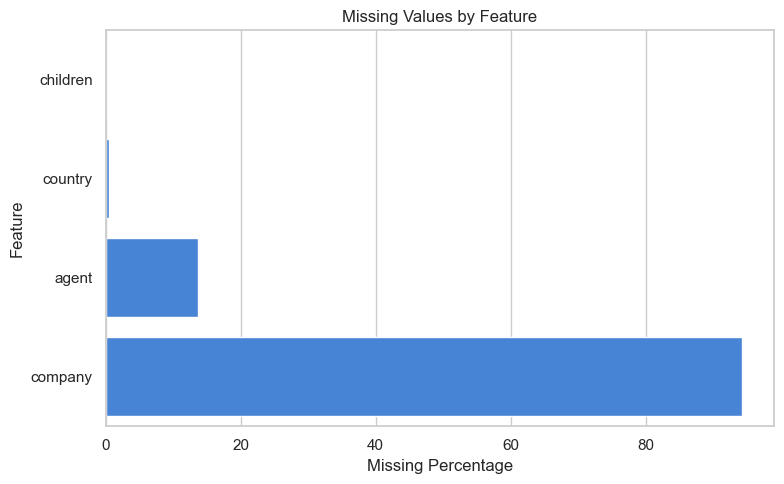

In [6]:
plt.figure(figsize=(8, 5))
missing_plot = missing_summary[missing_summary["missing_percentage"] > 0].head(10).sort_values("missing_percentage")
sns.barplot(data=missing_plot, x="missing_percentage", y=missing_plot.index, color="#2F80ED")
plt.title("Missing Values by Feature")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Baseline Model BEFORE Feature Engineering

In [7]:
leakage_columns = ["reservation_status", "reservation_status_date", "assigned_room_type"]
baseline_df = raw_df.drop(columns=leakage_columns).copy()

baseline_df["children"] = baseline_df["children"].fillna(0)
baseline_df["country"] = baseline_df["country"].fillna("Unknown")
baseline_df["agent"] = baseline_df["agent"].fillna(0)
baseline_df["company"] = baseline_df["company"].fillna(0)

X_base = baseline_df.drop(columns=["is_canceled"])
y = baseline_df["is_canceled"]
X_base_encoded = pd.get_dummies(X_base, drop_first=True)

Xb_train, Xb_test, y_train, y_test = train_test_split(
    X_base_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler_base = StandardScaler()
Xb_train_scaled = scaler_base.fit_transform(Xb_train)
Xb_test_scaled = scaler_base.transform(Xb_test)

baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_model.fit(Xb_train_scaled, y_train)

baseline_pred = baseline_model.predict(Xb_test_scaled)
baseline_prob = baseline_model.predict_proba(Xb_test_scaled)[:, 1]

def metrics_dict(name, y_true, y_pred, y_prob):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

baseline_metrics = metrics_dict("Before Feature Engineering", y_test, baseline_pred, baseline_prob)
pd.DataFrame([baseline_metrics])

,model,accuracy,precision,recall,f1,roc_auc
0,Before Feature Engineering,0.813845,0.808555,0.651781,0.721753,0.889874


## 8. Handling Missing Values

Missing values matter because they can hide business meaning.

In this dataset:

- missing `company` often means no company booking
- missing `agent` often means no agent
- missing `country` is unknown customer geography
- missing `children` can safely be treated as 0

We use domain-aware imputation instead of blindly dropping rows.

## 9. Encoding Categorical Variables

Models cannot directly understand text categories.

One-hot encoding turns category labels into binary switches.

`hotel = City Hotel` becomes a model-readable signal.

## 10. Feature Scaling

Logistic Regression benefits from scaling because optimization can be affected by feature magnitude.

Tree models do not usually need scaling because they split on thresholds.

## 11. Log Transformations and Skewness

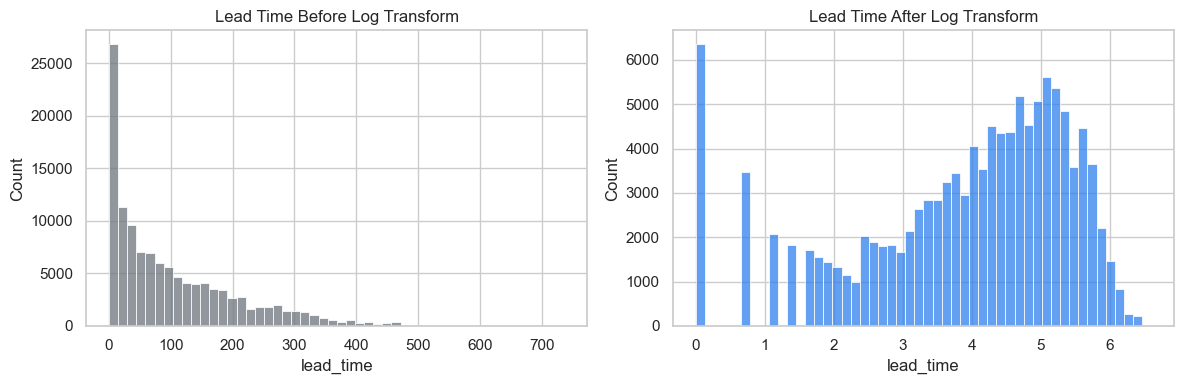

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(raw_df["lead_time"], bins=50, ax=axes[0], color="#6C757D")
axes[0].set_title("Lead Time Before Log Transform")
sns.histplot(np.log1p(raw_df["lead_time"]), bins=50, ax=axes[1], color="#2F80ED")
axes[1].set_title("Lead Time After Log Transform")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "feature_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Feature Creation

In [9]:
month_map = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}

engineered_df = raw_df.copy()
engineered_df["children"] = engineered_df["children"].fillna(0)
engineered_df["country"] = engineered_df["country"].fillna("Unknown")
engineered_df["agent"] = engineered_df["agent"].fillna(0)
engineered_df["company"] = engineered_df["company"].fillna(0)
engineered_df["arrival_month_number"] = engineered_df["arrival_date_month"].map(month_map)
engineered_df["arrival_date"] = pd.to_datetime(
    dict(
        year=engineered_df["arrival_date_year"],
        month=engineered_df["arrival_month_number"],
        day=engineered_df["arrival_date_day_of_month"],
    ),
    errors="coerce",
)
engineered_df["arrival_day_of_week"] = engineered_df["arrival_date"].dt.dayofweek
engineered_df["arrival_is_weekend"] = engineered_df["arrival_day_of_week"].isin([5, 6]).astype(int)
engineered_df["arrival_quarter"] = engineered_df["arrival_date"].dt.quarter
engineered_df["total_nights"] = engineered_df["stays_in_weekend_nights"] + engineered_df["stays_in_week_nights"]
engineered_df["total_guests"] = (engineered_df["adults"] + engineered_df["children"] + engineered_df["babies"]).replace(0, 1)
engineered_df["weekend_share"] = engineered_df["stays_in_weekend_nights"] / engineered_df["total_nights"].replace(0, 1)
engineered_df["adr_per_guest"] = engineered_df["adr"] / engineered_df["total_guests"]
engineered_df["special_requests_per_guest"] = engineered_df["total_of_special_requests"] / engineered_df["total_guests"]
engineered_df["has_children"] = ((engineered_df["children"] + engineered_df["babies"]) > 0).astype(int)
engineered_df["has_agent"] = (engineered_df["agent"] != 0).astype(int)
engineered_df["has_company"] = (engineered_df["company"] != 0).astype(int)
engineered_df["lead_time_log"] = np.log1p(engineered_df["lead_time"].clip(lower=0))
engineered_df["adr_log"] = np.log1p(engineered_df["adr"].clip(lower=0))
engineered_df["lead_time_x_total_nights"] = engineered_df["lead_time"] * engineered_df["total_nights"]
engineered_df["requests_x_parking"] = engineered_df["total_of_special_requests"] * engineered_df["required_car_parking_spaces"]
engineered_df["is_long_stay"] = (engineered_df["total_nights"] >= 7).astype(int)
engineered_df["is_last_minute"] = (engineered_df["lead_time"] <= 7).astype(int)
engineered_df["season"] = engineered_df["arrival_month_number"].map(
    lambda m: "winter" if m in [12, 1, 2] else "spring" if m in [3, 4, 5] else "summer" if m in [6, 7, 8] else "fall"
)

engineered_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,has_children,has_agent,has_company,lead_time_log,adr_log,lead_time_x_total_nights,requests_x_parking,is_long_stay,is_last_minute,season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0,0,5.837730,0.000000,0,0,0,0,summer
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0,0,6.603944,0.000000,0,0,0,0,summer
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,0,0,2.079442,4.330733,7,0,0,1,summer
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,1,0,2.639057,4.330733,13,0,0,0,summer
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,1,0,2.708050,4.595120,28,0,0,0,summer


## 13. Feature Selection

In [10]:
leakage_columns = ["reservation_status", "reservation_status_date", "assigned_room_type", "arrival_date"]
model_df = engineered_df.drop(columns=[c for c in leakage_columns if c in engineered_df.columns])
processed_columns = [
    "is_canceled", "hotel", "lead_time", "meal", "country", "market_segment", "distribution_channel",
    "reserved_room_type", "deposit_type", "customer_type", "previous_cancellations",
    "previous_bookings_not_canceled", "booking_changes", "days_in_waiting_list",
    "required_car_parking_spaces", "total_of_special_requests", "arrival_month_number",
    "arrival_day_of_week", "arrival_is_weekend", "arrival_quarter", "season", "total_nights",
    "total_guests", "weekend_share", "adr_per_guest", "special_requests_per_guest",
    "has_children", "has_agent", "has_company", "lead_time_log", "adr_log",
    "lead_time_x_total_nights", "requests_x_parking", "is_long_stay", "is_last_minute"
]
model_df[processed_columns].to_csv(DATA_PROCESSED, index=False)

X_eng = model_df.drop(columns=["is_canceled"])
y = model_df["is_canceled"]
X_eng_encoded = pd.get_dummies(X_eng, drop_first=True)

Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X_eng_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

selector = SelectKBest(score_func=mutual_info_classif, k=min(80, Xe_train.shape[1]))
Xe_train_selected = selector.fit_transform(Xe_train, ye_train)
Xe_test_selected = selector.transform(Xe_test)
selected_features = Xe_train.columns[selector.get_support()].tolist()

feature_scores = pd.DataFrame({
    "feature": Xe_train.columns,
    "score": selector.scores_,
}).sort_values("score", ascending=False)

display(feature_scores.head(15))

,feature,score
250,deposit_type_Non Refund,0.133660
33,lead_time_x_total_nights,0.093986
13,agent,0.081552
0,lead_time,0.081045
31,lead_time_log,0.079891
16,adr,0.076432
32,adr_log,0.076399
26,adr_per_guest,0.072702
187,country_PRT,0.063544
10,previous_cancellations,0.040459


## 14. Dimensionality Reduction Intuition

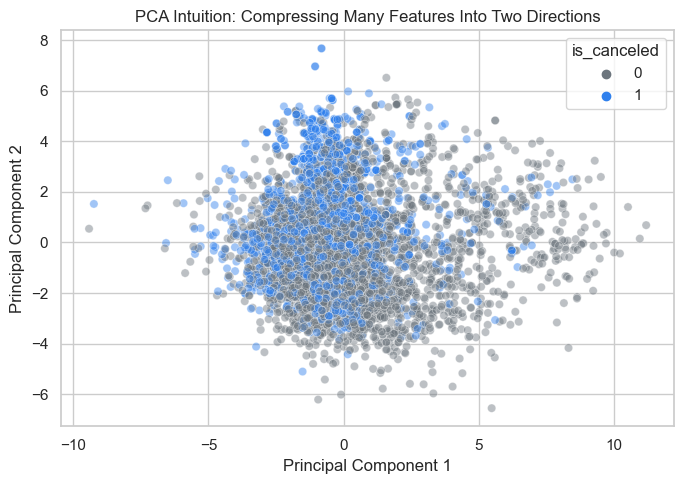

Variance explained: [0.086 0.069]


In [11]:
pca_sample = Xe_train[selected_features].sample(n=min(5000, len(Xe_train)), random_state=RANDOM_STATE)
pca_target = ye_train.loc[pca_sample.index]
pca_scaled = StandardScaler().fit_transform(pca_sample)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_components = pca.fit_transform(pca_scaled)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=pca_components[:, 0], y=pca_components[:, 1], hue=pca_target, alpha=0.45, palette=["#6C757D", "#2F80ED"])
plt.title("PCA Intuition: Compressing Many Features Into Two Directions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "pca_projection.png", dpi=300, bbox_inches="tight")
plt.show()

print("Variance explained:", pca.explained_variance_ratio_.round(3))

## 15. Target Leakage

Leakage is when the model sees information that would not exist at prediction time.

`reservation_status` and `reservation_status_date` directly reveal what happened to the booking, so they must be removed.

Leakage creates fake performance. It makes notebooks look amazing and production models fail.

## 16. Build Improved Model AFTER Feature Engineering

In [12]:
scaler_eng = StandardScaler()
Xe_train_scaled = scaler_eng.fit_transform(Xe_train_selected)
Xe_test_scaled = scaler_eng.transform(Xe_test_selected)

improved_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
improved_model.fit(Xe_train_scaled, ye_train)

improved_pred = improved_model.predict(Xe_test_scaled)
improved_prob = improved_model.predict_proba(Xe_test_scaled)[:, 1]
improved_metrics = metrics_dict("After Feature Engineering", ye_test, improved_pred, improved_prob)

comparison_df = pd.DataFrame([baseline_metrics, improved_metrics])
comparison_df

,model,accuracy,precision,recall,f1,roc_auc
0,Before Feature Engineering,0.813845,0.808555,0.651781,0.721753,0.889874
1,After Feature Engineering,0.819290,0.812845,0.665348,0.731738,0.897691


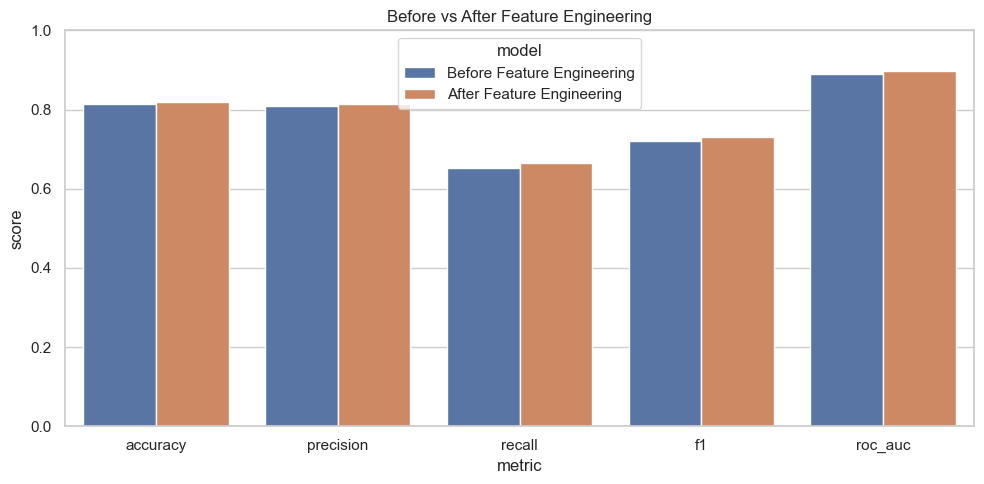

In [13]:
comparison_plot = comparison_df.melt(id_vars="model", value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"], var_name="metric", value_name="score")
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_plot, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title("Before vs After Feature Engineering")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Why the Model Improved

The improved model sees richer signals:

- stay length instead of separate weekday/weekend counts
- lead-time shape through log transform
- guest intensity through ratios
- arrival timing through date features
- booking behavior through interaction features

Feature engineering turns columns into clues.

## 18. Feature Importance

,feature,importance
75,deposit_type_Non Refund,0.199091
61,country_PRT,0.126168
0,lead_time,0.052792
28,lead_time_log,0.050458
8,previous_cancellations,0.049423
16,total_of_special_requests,0.048773
25,special_requests_per_guest,0.046390
30,lead_time_x_total_nights,0.041434
70,market_segment_Online TA,0.038009
76,customer_type_Transient,0.030921


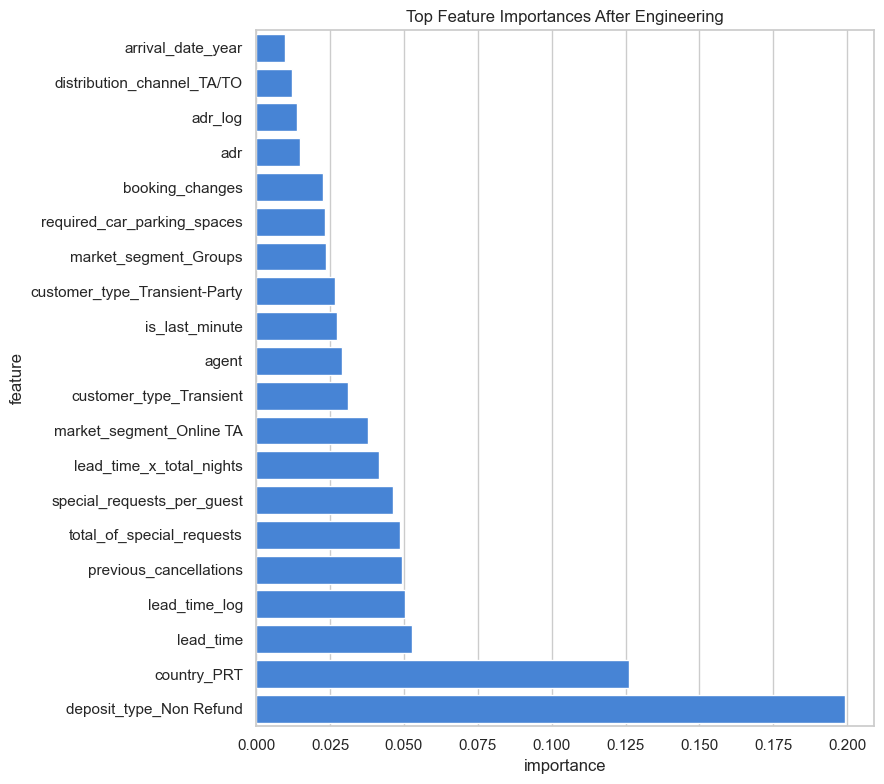

In [14]:
importance_model = RandomForestClassifier(n_estimators=250, max_depth=10, random_state=RANDOM_STATE, n_jobs=1)
importance_model.fit(Xe_train[selected_features], ye_train)

importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance": importance_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(9, 8))
top_importance = importance_df.head(20).sort_values("importance")
sns.barplot(data=top_importance, x="importance", y="feature", color="#2F80ED")
plt.title("Top Feature Importances After Engineering")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

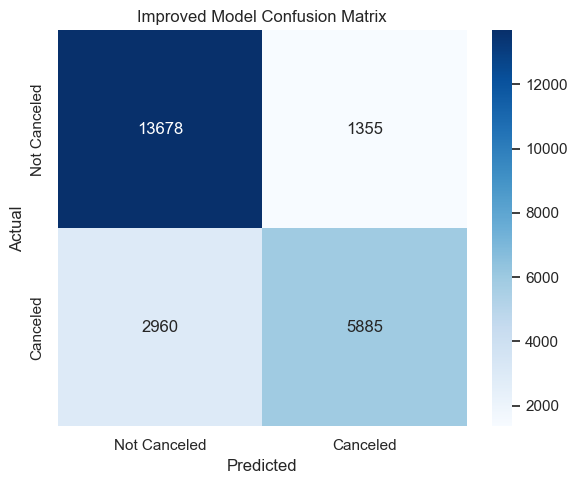

In [15]:
cm = confusion_matrix(ye_test, improved_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Canceled", "Canceled"], yticklabels=["Not Canceled", "Canceled"])
plt.title("Improved Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 19. Limitations

Feature engineering can also go wrong:

- too many noisy features can overfit
- leaky features create fake performance
- business assumptions may be wrong
- engineered features may be hard to maintain

## 20. Final Learnings

Better features can make the same model smarter.

Feature engineering is not cleanup. It is signal design.

## 21. Interview Questions

See:

`feature-engineering/interview_questions.md`